# <span style = 'color:red'> <center> Bellabeat: How Can a Wellness Technology Company Play It Smart? <center> <span>

<div style="width:100%;text-align: center;"> <img align=middle src="https://ecomblvd.com/wp-content/uploads/2019/03/bellabeat.png" alt="Heat beating" style="height:100px;margin-top:1rem;"> </div>

## <span style='color:red'> 1. Project Overview <span>
This project serves as the final milestone for the [Google Data Analytics Professional Certificate](https://www.coursera.org/professional-certificates/google-data-analytics). It involves the case study on [Bellabeat](https://bellabeat.com), a high-tech wellness company that manufactures health-focused smart products for women. Bellabeat offers a range of smart devices that collect health and lifestyle data, empowering women with insights into their own habits. These devices sync with the Bellabeat app to provide users with data regarding their activity, sleep, stress, menstrual cycle, and mindfulness habits, allowing them to better understand their current lifestyle and make informed, healthy decisions.

## <span style='color:red'> 2. Ask Phase <span>
#### <span style='color:black'> 2.1. Business Task <span>
The goal of this project is to analyze fitness data from non-Bellabeat smart devices to understand how consumers use their devices, in order to suggest improvements to Bellabeat products and support better marketing decisions. We will focus on answering the following key questions:
* What are some trends in smart device usage?
* How could these trends apply to Bellabeat customers?
* How could these trends help influence Bellabeat marketing strategy?

#### <span style='color:black'> 2.2. Key Stakeholders <span>
* Urška Sršen : Bellabeat cofounder and Chief Creative Officer
* Sando Mur : Bellabeat’s cofounder and key member of the Bellabeat executive team
  

## <span style='color:red'> 3. Prepare Phase <span>
#### <span style='color:black'> 3.1. Data Sources<span>
The [Fitbit Fitness Tracker Data](https://www.kaggle.com/arashnic/fitbit) from the Kaggle web repository will be used for this analysis. This dataset is made available under a CC0: Public Domain license, ensuring it is open for public use.

The data was generated by respondents to a distributed survey via Amazon Mechanical Turk between 03/12/2016 to 05/12/2016. It contains personal tracker data from 30 eligible FitBit users.

The dataset consists of 18 CSV files in total with each containing various health and activity metrics tracked by Fitbit.

#### <span style='color:black'> 3.2. Data Limitations <span>
* Sample size: 30 people is not a large enough sample to be representative of all FitBit users.

* Outdated: The dataset contains data from a one month period in 2016 only. For a deeper and more accurate analysis of trends, we would need data from the current year, preferably collected for an entire year to look at if trends vary during different times of year.

* Limited: The dataset does not contain any demographic information about the users, including gender, age, or location, which would be beneficial for marketing purposes to target specific customers.

#### <span style='color:black'> 3.3. Is Data ROCCC? <span>
A good data source is ROCCC which stands for **R**eliable, **O**riginal, **C**omprehensive, **C**urrent, and **C**ited.

1. Reliable - LOW - The dataset was collected from 30 FitBit users which is considered a small dataset, so might not be super reliable.

2. Original - LOW - It is a third party data collected from a survey via Amazon Mechanical Turk.

3. Comprehensive - MED - The dataset is comprehensive in terms of details which includes steps, calories, activity levels and sleep data of the users. However, the collected data spans across two months only which might be slightly insufficient.

4. Current - LOW - The dataset contains data between 03/12/2016 to 05/12/2016 which is around 10 years old.
5. Cited - LOW - While the source is identified (Kaggle), the data was collected by an unverified third party, and the methodology lacks transparency.

#### <span style='color:black'> 3.4. Data Selection <span>
Not all 18 CSV files were selected for this case study, as some files contained duplicate information or data that were not meaningful for the analysis. The selected CSV files used in this study are listed below:
| File Name | Description |
| --- | --- |
| dailyActivity_merged.csv | Daily Activity over 31 days of 33 IDs. Tracking daily: Steps, Distance, Intensities, Calories |
| hourlyCalories_merged.csv | Hourly Calories burned over 31 days of 33 IDs |
| hourlyIntensities_merged.csv | Hourly total and average intensity over 31 days of 33 IDs |
| hourlySteps_merged.csv | Hourly Steps over 31 days of 33 IDs |
| sleepDay_merged.csv | Total count of sleeps a day, Total minutes Asleep, Total Time in Bed of 24 IDs |

## <span style='color:red'> 4. Process Phase <span>

#### <span style='color:black'> 4.1 Importing required libraries <span>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rich import print

#### <span style='color:black'> 4.2 Importing and Previewing Dataframes <span>

In [4]:
# Load CSV files into pandas DataFrames
daily_activity_df = pd.read_csv('/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/dailyActivity_merged.csv')
hourly_calories_df = pd.read_csv('/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/hourlyCalories_merged.csv')
hourly_intensities_df = pd.read_csv('/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/hourlyIntensities_merged.csv')
hourly_steps_df = pd.read_csv('/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/hourlySteps_merged.csv')
sleep_day_df = pd.read_csv('/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/sleepDay_merged.csv')

In [5]:
# Display the first 5 rows of each DataFrame
print("[bold]daily_activity[/bold]")
display(daily_activity_df.head())

print("[bold]hourly_calories[/bold]")
display(hourly_calories_df.head())

print("[bold]hourly_intensities[/bold]")
display(hourly_intensities_df.head())

print("[bold]hourly_steps[/bold]")
display(hourly_steps_df.head())

print("[bold]sleep_day[/bold]")
display(sleep_day_df.head())

daily_activity

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,4/12/2016,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985
1,1503960366,4/13/2016,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797
2,1503960366,4/14/2016,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776
3,1503960366,4/15/2016,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745
4,1503960366,4/16/2016,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863


hourly_calories

,Id,ActivityHour,Calories
0,1503960366,4/12/2016 12:00:00 AM,81
1,1503960366,4/12/2016 1:00:00 AM,61
2,1503960366,4/12/2016 2:00:00 AM,59
3,1503960366,4/12/2016 3:00:00 AM,47
4,1503960366,4/12/2016 4:00:00 AM,48


hourly_intensities

,Id,ActivityHour,TotalIntensity,AverageIntensity
0,1503960366,4/12/2016 12:00:00 AM,20,0.333333
1,1503960366,4/12/2016 1:00:00 AM,8,0.133333
2,1503960366,4/12/2016 2:00:00 AM,7,0.116667
3,1503960366,4/12/2016 3:00:00 AM,0,0.000000
4,1503960366,4/12/2016 4:00:00 AM,0,0.000000


hourly_steps

,Id,ActivityHour,StepTotal
0,1503960366,4/12/2016 12:00:00 AM,373
1,1503960366,4/12/2016 1:00:00 AM,160
2,1503960366,4/12/2016 2:00:00 AM,151
3,1503960366,4/12/2016 3:00:00 AM,0
4,1503960366,4/12/2016 4:00:00 AM,0


sleep_day

,Id,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
0,1503960366,4/12/2016 12:00:00 AM,1,327,346
1,1503960366,4/13/2016 12:00:00 AM,2,384,407
2,1503960366,4/15/2016 12:00:00 AM,1,412,442
3,1503960366,4/16/2016 12:00:00 AM,2,340,367
4,1503960366,4/17/2016 12:00:00 AM,1,700,712


In [6]:
# Display basic information about DataFrames
print("[bold]daily_activity[/bold]")
display(daily_activity_df.info())

print("[bold]hourly_calories[/bold]")
display(hourly_calories_df.info())

print("[bold]hourly_intensities[/bold]")
display(hourly_intensities_df.info())

print("[bold]hourly_steps[/bold]")
display(hourly_steps_df.info())

print("[bold]sleep_day[/bold]")
display(sleep_day_df.info())

daily_activity

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 940 entries, 0 to 939
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Id                        940 non-null    int64  
 1   ActivityDate              940 non-null    object 
 2   TotalSteps                940 non-null    int64  
 3   TotalDistance             940 non-null    float64
 4   TrackerDistance           940 non-null    float64
 5   LoggedActivitiesDistance  940 non-null    float64
 6   VeryActiveDistance        940 non-null    float64
 7   ModeratelyActiveDistance  940 non-null    float64
 8   LightActiveDistance       940 non-null    float64
 9   SedentaryActiveDistance   940 non-null    float64
 10  VeryActiveMinutes         940 non-null    int64  
 11  FairlyActiveMinutes       940 non-null    int64  
 12  LightlyActiveMinutes      940 non-null    int64  
 13  SedentaryMinutes          940 non-null    int64  
 14  Calories  

None

hourly_calories

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22099 entries, 0 to 22098
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Id            22099 non-null  int64 
 1   ActivityHour  22099 non-null  object
 2   Calories      22099 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 518.1+ KB


...

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22099 entries, 0 to 22098
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Id            22099 non-null  int64 
 1   ActivityHour  22099 non-null  object
 2   StepTotal     22099 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 518.1+ KB


None

sleep_day

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 413 entries, 0 to 412
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Id                  413 non-null    int64 
 1   SleepDay            413 non-null    object
 2   TotalSleepRecords   413 non-null    int64 
 3   TotalMinutesAsleep  413 non-null    int64 
 4   TotalTimeInBed      413 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 16.3+ KB


None

<div style="background-color: lightyellow; padding: 10px;">

After previewing the DataFrames, we noticed the following:

* The data types of the `ActivityDate`, `ActivityHour`, and `SleepDay` columns are currently in object format, so we will convert them later to datetime format.
* The data type of the `Id` column is int64, but since we will not perform mathematical operations on it, we will convert it later to string format.
</div>


#### <span style='color:black'> 4.3 Data Cleaning and Manipulation <span>

<div style="background-color: lightyellow; padding: 10px;">
    
We will perform the following steps :
  1. Remove duplicates and nulls
  2. Adjust data types and Rename columns
  3. Merge DataFrames if necessary
</div>


##### <span style='color:black'> 4.3.1 Check for duplicates and remove them <span>

In [7]:
# Check for duplicates
print(f'daily_activity has {daily_activity_df.duplicated().sum()} duplicates')
print(f'hourly_intensities has {hourly_intensities_df.duplicated().sum()} duplicates')
print(f'hourly_calories has {hourly_calories_df.duplicated().sum()} duplicates')
print(f'hourly_steps has {hourly_steps_df.duplicated().sum()} duplicates')
print(f'sleep_day has {sleep_day_df.duplicated().sum()} duplicates')

daily_activity has 0 duplicates

hourly_intensities has 0 duplicates

hourly_calories has 0 duplicates

hourly_steps has 0 duplicates

sleep_day has 3 duplicates

<div style="background-color: lightyellow; padding: 10px;">

We found 3 duplicates in `sleep_day` DataFrame
</div>

In [8]:
# Remove duplicate rows from the sleep_day DataFrame
sleep_day_df.drop_duplicates()

,Id,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
0,1503960366,4/12/2016 12:00:00 AM,1,327,346
1,1503960366,4/13/2016 12:00:00 AM,2,384,407
2,1503960366,4/15/2016 12:00:00 AM,1,412,442
3,1503960366,4/16/2016 12:00:00 AM,2,340,367
4,1503960366,4/17/2016 12:00:00 AM,1,700,712
...,...,...,...,...,...
408,8792009665,4/30/2016 12:00:00 AM,1,343,360
409,8792009665,5/1/2016 12:00:00 AM,1,503,527
410,8792009665,5/2/2016 12:00:00 AM,1,415,423
411,8792009665,5/3/2016 12:00:00 AM,1,516,545


##### <span style='color:black'> 4.3.2 Check for nulls and remove them <span>

In [9]:
# Check for nulls
print(f'daily_activity has {daily_activity_df.isnull().sum().sum()} nulls')
print(f'hourly_intensities has {hourly_intensities_df.isnull().sum().sum()} nulls')
print(f'hourly_calories has {hourly_calories_df.isnull().sum().sum()} nulls')
print(f'hourly_steps has {hourly_steps_df.isnull().sum().sum()} nulls')
print(f'sleep_day has {sleep_day_df.isnull().sum().sum()} nulls')

daily_activity has 0 nulls

hourly_intensities has 0 nulls

hourly_calories has 0 nulls

hourly_steps has 0 nulls

sleep_day has 0 nulls

<div style="background-color: lightyellow; padding: 10px;">

We did not find any null values, so we do not need to remove them.
</div>

##### <span style='color:black'> 4.3.3 Adjust data types and rename columns<span>

<div style="background-color: lightyellow; padding: 10px;">

Earlier, we found that the data types of the `ActivityDate`, `ActivityHour`, and `SleepDay` columns are in object format, so we will convert them to datetime format. We will also convert the `Id` column data type from int64 to string, since it serves as an identifier rather than a numeric value.

</div>

In [10]:
# Convert to datetime format
daily_activity_df['ActivityDate'] = pd.to_datetime(daily_activity_df['ActivityDate'])
hourly_intensities_df['ActivityHour'] = pd.to_datetime(hourly_intensities_df['ActivityHour'])
hourly_calories_df['ActivityHour'] = pd.to_datetime(hourly_calories_df['ActivityHour'])
hourly_steps_df['ActivityHour'] = pd.to_datetime(hourly_steps_df['ActivityHour'])
sleep_day_df['SleepDay'] = pd.to_datetime(sleep_day_df['SleepDay'])

/tmp/ipykernel_73/985236524.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  hourly_intensities_df['ActivityHour'] = pd.to_datetime(hourly_intensities_df['ActivityHour'])
/tmp/ipykernel_73/985236524.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  hourly_calories_df['ActivityHour'] = pd.to_datetime(hourly_calories_df['ActivityHour'])
/tmp/ipykernel_73/985236524.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  hourly_steps_df['ActivityHour'] = pd.to_datetime(hourly_steps_df['ActivityHour'])
/tmp/ipykernel_73/985236524.py:6: UserWarning: Could not infer format, so ea

In [11]:
# Split the SleepDay column into SleepDate and SleepTime columns
sleep_day_df['SleepDate'] = sleep_day_df['SleepDay']
sleep_day_df['SleepTime'] = sleep_day_df['SleepDay'].dt.time

# Drop the original SleepDay column if no longer needed
sleep_day_df = sleep_day_df.drop(columns=['SleepDay'])

# Reorder columns
sleep_day_df = sleep_day_df[['Id', 'SleepDate', 'SleepTime',
                             'TotalSleepRecords', 'TotalMinutesAsleep', 'TotalTimeInBed']]

In [12]:
sleep_day_df['SleepTime'].value_counts()

SleepTime
00:00:00    413
Name: count, dtype: int64

<div style="background-color: lightyellow; padding: 10px;">

We noticed that the same sleep time is repeated in all rows, so this column does not provide relevant information and can be dropped. However, we can add a `DayOfWeek` column to both the sleep_day and daily_activity DataFrames, which will be very useful for further analysis.

</div>

In [13]:
# Add DayOfWeek column 
sleep_day_df['DayOfWeek'] = sleep_day_df['SleepDate'].dt.day_name()
daily_activity_df['DayOfWeek'] = daily_activity_df['ActivityDate'].dt.day_name()

# Reorder columns so DayOfWeek comes right after the date column
sleep_day_df = sleep_day_df[['Id', 'SleepDate', 'DayOfWeek', 'TotalSleepRecords',
                             'TotalMinutesAsleep', 'TotalTimeInBed']]
daily_activity_df = daily_activity_df[['Id', 'ActivityDate', 'DayOfWeek', 'TotalSteps',
                                   'TotalDistance', 'TrackerDistance', 'LoggedActivitiesDistance',
                                   'VeryActiveDistance', 'ModeratelyActiveDistance', 'LightActiveDistance',
                                   'SedentaryActiveDistance', 'VeryActiveMinutes', 'FairlyActiveMinutes',
                                   'LightlyActiveMinutes', 'SedentaryMinutes', 'Calories']]

In [14]:
# Convert to string format
daily_activity_df['Id'] = daily_activity_df['Id'].astype(str)
hourly_intensities_df['Id'] = hourly_intensities_df['Id'].astype(str)
hourly_calories_df['Id'] = hourly_calories_df['Id'].astype(str)
hourly_steps_df['Id'] = hourly_steps_df['Id'].astype(str)
sleep_day_df['Id'] = sleep_day_df['Id'].astype(str)

In [15]:
# Rename some columns
hourly_steps_df = hourly_steps_df.rename(columns={'StepTotal': 'TotalSteps', 'ActivityHour': 'ActivityTime'})
hourly_intensities_df = hourly_intensities_df.rename(columns={'ActivityHour': 'ActivityTime'})
hourly_calories_df = hourly_calories_df.rename(columns={'ActivityHour': 'ActivityTime'})

<div style="background-color: lightyellow; padding: 10px;">
    
Now let's take a look at the transformed DataFrames.
</div>

In [16]:
print("[bold]daily_activity[/bold]")
display(daily_activity_df.head())

print("[bold]hourly_calories[/bold]")
display(hourly_calories_df.head())

print("[bold]hourly_intensities[/bold]")
display(hourly_intensities_df.head())

print("[bold]hourly_steps[/bold]")
display(hourly_steps_df.head())

print("[bold]sleep_day[/bold]")
display(sleep_day_df.head())

daily_activity

,Id,ActivityDate,DayOfWeek,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,2016-04-12,Tuesday,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985
1,1503960366,2016-04-13,Wednesday,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797
2,1503960366,2016-04-14,Thursday,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776
3,1503960366,2016-04-15,Friday,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745
4,1503960366,2016-04-16,Saturday,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863


hourly_calories

,Id,ActivityTime,Calories
0,1503960366,2016-04-12 00:00:00,81
1,1503960366,2016-04-12 01:00:00,61
2,1503960366,2016-04-12 02:00:00,59
3,1503960366,2016-04-12 03:00:00,47
4,1503960366,2016-04-12 04:00:00,48


hourly_intensities

,Id,ActivityTime,TotalIntensity,AverageIntensity
0,1503960366,2016-04-12 00:00:00,20,0.333333
1,1503960366,2016-04-12 01:00:00,8,0.133333
2,1503960366,2016-04-12 02:00:00,7,0.116667
3,1503960366,2016-04-12 03:00:00,0,0.000000
4,1503960366,2016-04-12 04:00:00,0,0.000000


hourly_steps

,Id,ActivityTime,TotalSteps
0,1503960366,2016-04-12 00:00:00,373
1,1503960366,2016-04-12 01:00:00,160
2,1503960366,2016-04-12 02:00:00,151
3,1503960366,2016-04-12 03:00:00,0
4,1503960366,2016-04-12 04:00:00,0


sleep_day

,Id,SleepDate,DayOfWeek,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
0,1503960366,2016-04-12,Tuesday,1,327,346
1,1503960366,2016-04-13,Wednesday,2,384,407
2,1503960366,2016-04-15,Friday,1,412,442
3,1503960366,2016-04-16,Saturday,2,340,367
4,1503960366,2016-04-17,Sunday,1,700,712


##### <span style='color:black'> 4.3.4 Merge DataFrames<span>

<div style="background-color: lightyellow; padding: 10px;">
    
In the DataFrames `hourly_intensities`, `hourly_calories`, and `hourly_steps`, we noticed that they share the same first two columns (`Id` and `ActivityHour`) and also have the same number of rows (22,099). Therefore, we can merge them into a single DataFrame.

</div>


In [17]:
# Merge hourly dataframes
hourly_metrics_df = hourly_calories_df.merge(hourly_intensities_df,on=['Id','ActivityTime'],how='left')\
.merge(hourly_steps_df,on=['Id','ActivityTime'],how='left')

# Preview the first 5 rows of hourly_metrics_df
hourly_metrics_df.head()

,Id,ActivityTime,Calories,TotalIntensity,AverageIntensity,TotalSteps
0,1503960366,2016-04-12 00:00:00,81,20,0.333333,373
1,1503960366,2016-04-12 01:00:00,61,8,0.133333,160
2,1503960366,2016-04-12 02:00:00,59,7,0.116667,151
3,1503960366,2016-04-12 03:00:00,47,0,0.000000,0
4,1503960366,2016-04-12 04:00:00,48,0,0.000000,0


<div style="background-color: lightyellow; padding: 10px;">
    
However, we cannot merge the `sleep_day` and `daily_activity` DataFrames, even though both contain daily metrics. The reason is that the `sleep_day` DataFrame has only 410 entries after removing duplicates, while the `daily_activity` DataFrame has 940 entries covering day‑to‑day recorded metrics from 03/12/2016 to 05/12/2016. Since sleep_day does not have complete records, we will keep each DataFrame as it is without merging them.

</div>

## <span style='color:red'> 5. Analyze and Share Phase <span>

#### <span style='color:black'> 5.1 Summary Statistics <span>

In [65]:
cols = set(daily_activity_df.columns) - {'Id', 'ActivityDate', 'DayOfWeek'}
summary_daily_activity = daily_activity_df[sorted(list(cols))]
print("[bold]daily_activity summary[/bold]")
summary_daily_activity.describe().round(2)

daily_activity summary

,Calories,FairlyActiveMinutes,LightActiveDistance,LightlyActiveMinutes,LoggedActivitiesDistance,ModeratelyActiveDistance,SedentaryActiveDistance,SedentaryMinutes,TotalDistance,TotalSteps,TrackerDistance,VeryActiveDistance,VeryActiveMinutes
count,940.00,940.00,940.00,940.00,940.00,940.00,940.00,940.00,940.00,940.00,940.00,940.00,940.00
mean,2303.61,13.56,3.34,192.81,0.11,0.57,0.00,991.21,5.49,7637.91,5.48,1.50,21.16
std,718.17,19.99,2.04,109.17,0.62,0.88,0.01,301.27,3.92,5087.15,3.91,2.66,32.84
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,1828.50,0.00,1.95,127.00,0.00,0.00,0.00,729.75,2.62,3789.75,2.62,0.00,0.00
50%,2134.00,6.00,3.36,199.00,0.00,0.24,0.00,1057.50,5.24,7405.50,5.24,0.21,4.00
75%,2793.25,19.00,4.78,264.00,0.00,0.80,0.00,1229.50,7.71,10727.00,7.71,2.05,32.00
max,4900.00,143.00,10.71,518.00,4.94,6.48,0.11,1440.00,28.03,36019.00,28.03,21.92,210.00


In [66]:
cols = set(sleep_day_df.columns) - {'Id', 'SleepDate', 'DayOfWeek', 'SleepCategory', 'SleepHours'}
summary_sleep_day = sleep_day_df[sorted(list(cols))]
print("[bold]sleep_day summary[/bold]")
summary_sleep_day.describe().round(2)

sleep_day summary

,AwakeTimeInbed,TotalMinutesAsleep,TotalSleepRecords,TotalTimeInBed
count,413.00,413.00,413.00,413.00
mean,39.17,419.47,1.12,458.64
std,46.57,118.34,0.35,127.10
min,0.00,58.00,1.00,61.00
25%,17.00,361.00,1.00,403.00
50%,25.00,433.00,1.00,463.00
75%,40.00,490.00,1.00,526.00
max,371.00,796.00,3.00,961.00


In [67]:
cols = set(hourly_metrics_df.columns) - {'Id', 'ActivityTime'}
summary_hourly_metrics = hourly_metrics_df[sorted(list(cols))]
print("[bold]hourly_metrics summary[/bold]")
summary_hourly_metrics.describe().round(2)

hourly_metrics summary

,AverageIntensity,Calories,Hour,TotalIntensity,TotalSteps
count,22099.00,22099.00,22099.00,22099.00,22099.00
mean,0.20,97.39,11.42,12.04,320.17
std,0.35,60.70,6.92,21.13,690.38
min,0.00,42.00,0.00,0.00,0.00
25%,0.00,63.00,5.00,0.00,0.00
50%,0.05,83.00,11.00,3.00,40.00
75%,0.27,108.00,17.00,16.00,357.00
max,3.00,948.00,23.00,180.00,10554.00


<div style="background-color: lightyellow; padding: 10px;">

**Key takeaways from the summary statistics:**

* **Daily Activity:** The average user takes approximately **7,638 steps/day**, falling short of the commonly recommended 10,000 steps. Average calories burned per day is around **2,304 kcal**. Sedentary minutes dominate at a mean of **991 minutes/day** (~16.5 hours), while very active and fairly active minutes are very low (mean of ~21 and ~14 minutes respectively).

* **Sleep:** On average, users sleep approximately **419 minutes (~7 hours)** per night, which falls within the recommended 7–9 hours for adults. However, the minimum of 58 minutes and maximum of 796 minutes indicate significant variation across users. Users spend on average **39 minutes awake in bed** before falling asleep or after waking up.

* **Hourly Metrics:** Peak hourly activity aligns with daytime hours. The average hourly step count is around **320 steps**, and average calories burned per hour is about **97 kcal**, both of which spike during late morning, afternoon, and evening hours as we will explore in sections below.
</div>

#### <span style='color:black'> 5.2 Average Steps per Day Of Week<span>

In [68]:
# Group by weekday and calculate the average steps
avg_steps_per_day = daily_activity_df.groupby('DayOfWeek')['TotalSteps'].mean()

# Reorder weekdays
weekday_order = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
avg_steps_per_day = avg_steps_per_day.reindex(weekday_order)

# Convert to DataFrame
avg_steps_per_day_df = avg_steps_per_day.reset_index()
avg_steps_per_day_df.columns = ['DayOfWeek', 'AverageSteps']
avg_steps_per_day_df['AverageSteps'] = avg_steps_per_day_df['AverageSteps'].round(0).astype(int)

display(avg_steps_per_day_df)

,DayOfWeek,AverageSteps
0,Sunday,6933
1,Monday,7781
2,Tuesday,8125
3,Wednesday,7559
4,Thursday,7406
5,Friday,7448
6,Saturday,8153


<div style="background-color: lightyellow; padding: 10px;">

The table shows the average total steps per day of the week. **Saturday (8,153) and Tuesday (8,125)** stand out as the most active days, while **Sunday (6,933)** records the lowest average — likely a rest day for many users. Notably, all days fall below the commonly recommended 10,000 steps/day, indicating a general under-activity trend in this dataset. The following box plot will provide a fuller picture by showing the distribution of steps, not just the average.
</div>

#### <span style='color:black'> 5.3 Distribution of Total Steps by Day of Week <span>

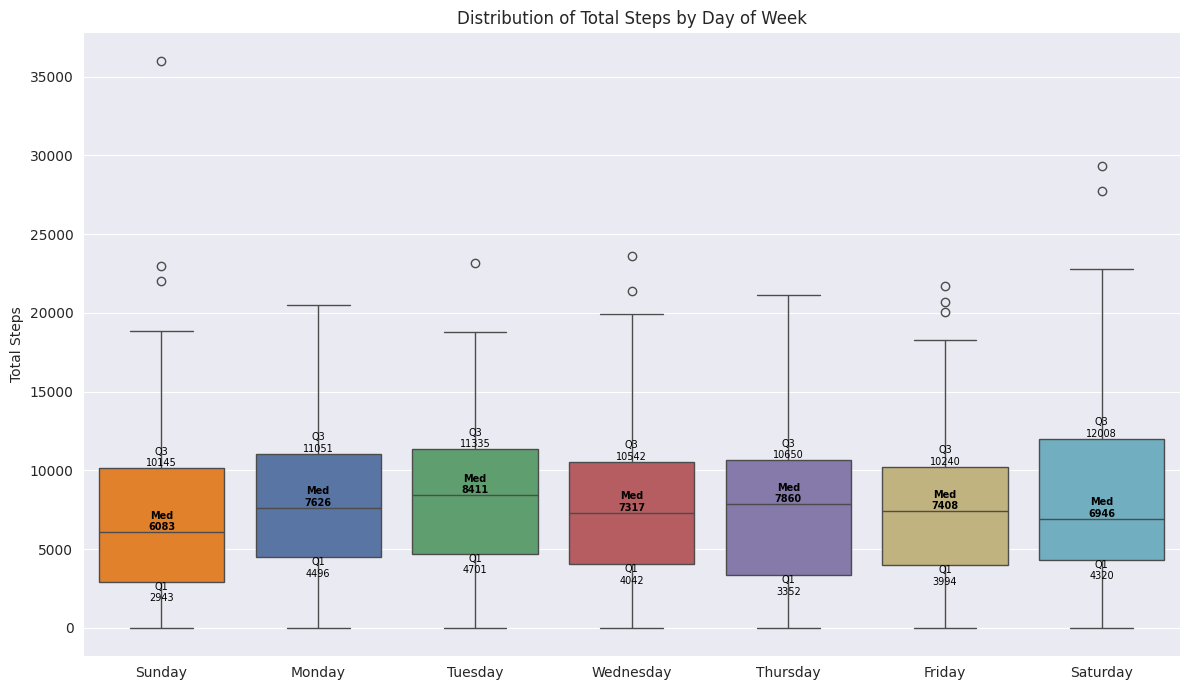

In [69]:
day_order = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']

day_palette = {
    'Monday'    : '#4C72B0',
    'Tuesday'   : '#55A868',
    'Wednesday' : '#C44E52',
    'Thursday'  : '#8172B2',
    'Friday'    : '#CCB974',
    'Saturday'  : '#64B5CD',
    'Sunday'    : '#FF7F0E'
}

sns.set_style('darkgrid')
fig, ax = plt.subplots(figsize=(12, 7))
sns.boxplot(
    x='DayOfWeek',
    y='TotalSteps',
    data=daily_activity_df,
    order=day_order,
    hue='DayOfWeek',
    palette=day_palette,
    legend=False,
    ax=ax
)

# Annotate each boxplot with Q1, Median, Q3
for i, day in enumerate(day_order):
    day_data = daily_activity_df[daily_activity_df['DayOfWeek'] == day]['TotalSteps']
    q1     = day_data.quantile(0.25)
    median = day_data.median()
    q3     = day_data.quantile(0.75)
    ax.text(i, median, f'Med\n{median:.0f}', ha='center', va='bottom', fontsize=7, fontweight='bold', color='black')
    ax.text(i, q1,     f'Q1\n{q1:.0f}',      ha='center', va='top',    fontsize=7, color='black')
    ax.text(i, q3,     f'Q3\n{q3:.0f}',      ha='center', va='bottom', fontsize=7, color='black')

plt.title('Distribution of Total Steps by Day of Week')
plt.xlabel('')
plt.ylabel('Total Steps')
plt.tight_layout()
plt.show()

<div style="background-color: lightyellow; padding: 10px;">

The box plot reveals the full distribution of steps across the week:

* **Tuesday has the highest median (8,411 steps)**, making it the single most active day. Saturday also shows a high median (7,991), confirming it as a consistently active day.
* **Sunday has the lowest median (6,083 steps)**, reinforcing the pattern that it is a rest/recovery day for most users.
* **The interquartile range (Q1–Q3) is wide across all days**, indicating substantial variability in how active different users are. For example, on Saturday Q1 is around 3,900 and Q3 around 12,300, a range of nearly 8,400 steps — weekend behavior is more polarized.
* **Outliers (very high step counts) appear on every day**, suggesting that a minority of users are consistently very active regardless of the day.
* Overall, no day shows a median above 10,000 steps, which means the **majority of users consistently fall below the recommended daily step goal throughout the entire week**.
</div>

#### 5.4 Average Steps per Hour of Day

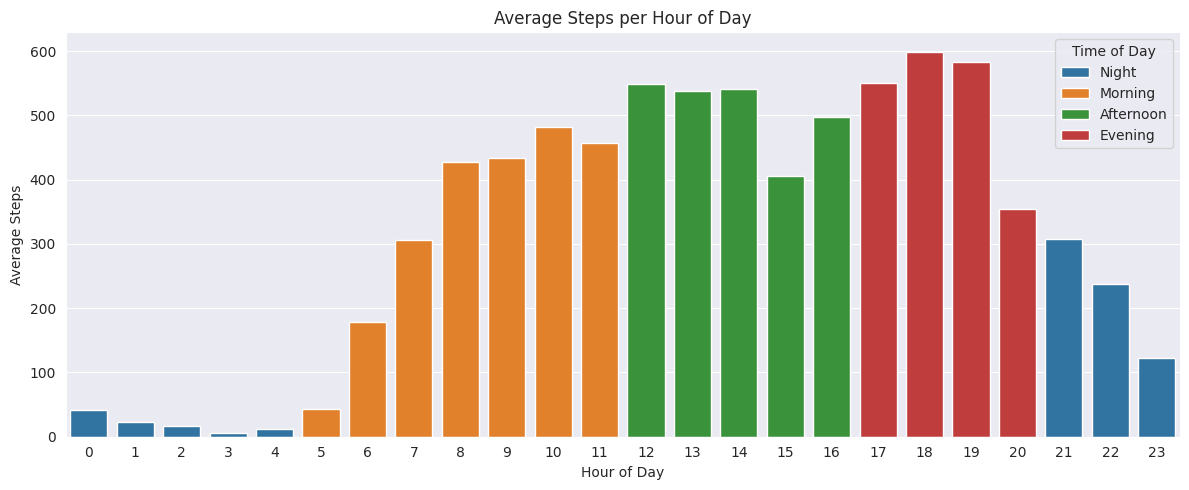

In [70]:
# Extract hour column
hourly_metrics_df['Hour'] = hourly_metrics_df['ActivityTime'].dt.hour

# Calculate the mean per hour
avg_steps_per_hour = hourly_metrics_df.groupby('Hour')['TotalSteps'].mean().reset_index()

# Time category function
def get_time_category(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

avg_steps_per_hour['TimeCategory'] = avg_steps_per_hour['Hour'].apply(get_time_category)

plt.figure(figsize=(12, 5))
sns.barplot(
    data=avg_steps_per_hour,
    x='Hour',
    y='TotalSteps',
    hue='TimeCategory',
    dodge=False
)
plt.xlabel('Hour of Day')
plt.ylabel('Average Steps')
plt.title('Average Steps per Hour of Day')
plt.xticks(range(0, 24))
plt.legend(title='Time of Day')
plt.tight_layout()
plt.show()

<div style="background-color: lightyellow; padding: 10px;">

The chart reveals a clear daily rhythm in step activity:

* **Activity is minimal from midnight to 5 AM**, as expected during sleep hours, with the absolute lowest point at 3 AM.
* **Activity picks up from 6 AM onwards** and grows steadily through the morning.
* **Two clear peaks emerge:** one around **12 PM–2 PM** (lunch break or midday movement) and a stronger peak at **5 PM–7 PM** (post-work activity — commuting, exercising, or evening walks).
* **The 6 PM hour records the highest average step count**, suggesting that evening is the most popular time for physical activity among users.
* **Activity drops sharply after 8 PM** as users wind down for the night.

This pattern suggests that users have two natural windows for activity: **midday and early evening** — both of which are valuable moments for Bellabeat to deliver wellness nudges or activity reminders.
</div>

#### <span style='color:black'> 5.5 Distribution of Different Activity Levels <span>

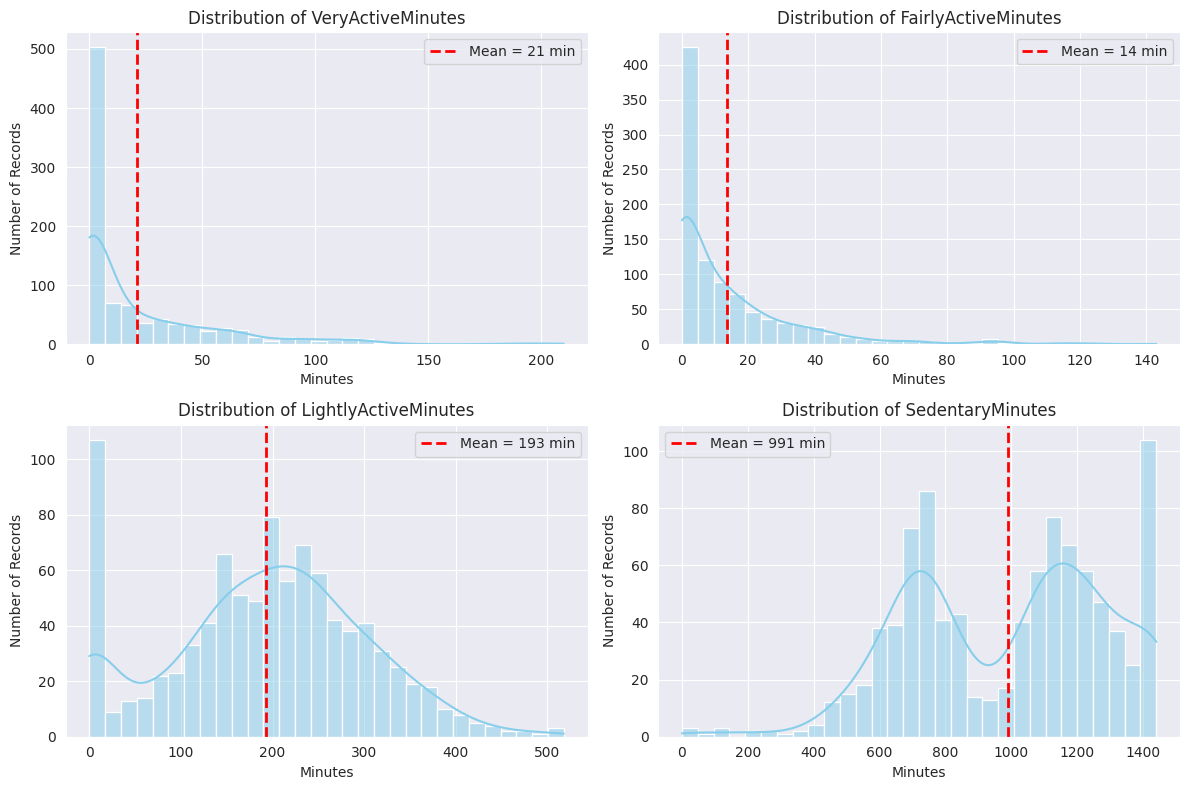

In [71]:
cols = ['VeryActiveMinutes', 'FairlyActiveMinutes', 'LightlyActiveMinutes', 'SedentaryMinutes']

plt.figure(figsize=(12, 8))

for i, col in enumerate(cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(daily_activity_df[col], bins=30, kde=True, color='skyblue', stat='count')
    mean_val = daily_activity_df[col].mean()
    plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean = {mean_val:.0f} min')
    plt.title(f'Distribution of {col}')
    plt.xlabel('Minutes')
    plt.ylabel('Number of Records')
    plt.legend()

plt.tight_layout()
plt.show()

<div style="background-color: lightyellow; padding: 10px;">

* **Very Active Minutes:** The distribution is strongly right-skewed, with most records concentrated at very low values. This indicates that users spend very little time in intense physical activity, and only a small number of days include longer periods of high-intensity exercise. Examples of very active activities include running, fast cycling, high-intensity interval training (HIIT), or competitive sports.

* **Fairly Active Minutes:** This distribution is also right-skewed, suggesting that users engage in moderate-intensity activities for relatively short periods during the day. Only a limited number of records show higher values of fairly active minutes. Examples of fairly active activities include brisk walking, casual cycling, or recreational sports.

* **Lightly Active Minutes:** The distribution is more centered around the mean, indicating that users spend a considerable amount of time performing light-intensity activities. This suggests that light movement represents the most common form of daily activity among users. Examples of lightly active activities include slow walking, household chores, light stretching, or moving around at work.

* **Sedentary Minutes:** The distribution is bimodal, with two noticeable peaks around 700–800 minutes and 1,100–1,200 minutes, suggesting that there may be two common patterns of sedentary behavior among users: one group with moderately high sedentary time and another group with very high sedentary time. Examples of sedentary activities include sitting at a desk, watching television, driving, or using a computer or phone.

<div style="background-color: lightyellow; padding: 10px;">

The histograms reveal distinct distribution patterns for each activity level:

* **Very Active Minutes:** Strongly right-skewed. The vast majority of records cluster near zero, meaning most days users spend little to no time in high-intensity exercise (mean ≈ 21 min). Only a small proportion of days include meaningful very active periods (e.g., running, HIIT, fast cycling).

* **Fairly Active Minutes:** Also right-skewed, though less extreme. Users occasionally engage in moderate-intensity activities (brisk walking, recreational sports), but these are not a daily habit for most. Mean ≈ 14 minutes.

* **Lightly Active Minutes:** More symmetrically distributed around the mean (≈192 min). This is the dominant form of active behavior — slow walking, household chores, casual movement. It forms the backbone of daily physical activity for most users.

* **Sedentary Minutes:** Shows a **bimodal distribution** with two prominent peaks around 700–800 min and 1,100-1,200 min. This suggests two distinct user segments: one group that is moderately sedentary (~12 hrs) and another that is heavily sedentary (~18-20 hrs). This bimodality is an important signal worth investigating for targeted wellness interventions.
</div>

#### <span style='color:black'> 5.6 Average Time Spent per Activity Level <span>

In [72]:
# Calculate average time per activity level
avg_time_per_activity = daily_activity_df[[
    'VeryActiveMinutes', 'FairlyActiveMinutes', 'LightlyActiveMinutes', 'SedentaryMinutes'
]].mean().reset_index()
avg_time_per_activity.columns = ['ActivityLevel', 'AvgMinutes']
avg_time_per_activity['AvgMinutes'] = avg_time_per_activity['AvgMinutes'].round(1)
avg_time_per_activity['AvgHours'] = (avg_time_per_activity['AvgMinutes'] / 60).round(2)
display(avg_time_per_activity)

,ActivityLevel,AvgMinutes,AvgHours
0,VeryActiveMinutes,21.2,0.35
1,FairlyActiveMinutes,13.6,0.23
2,LightlyActiveMinutes,192.8,3.21
3,SedentaryMinutes,991.2,16.52


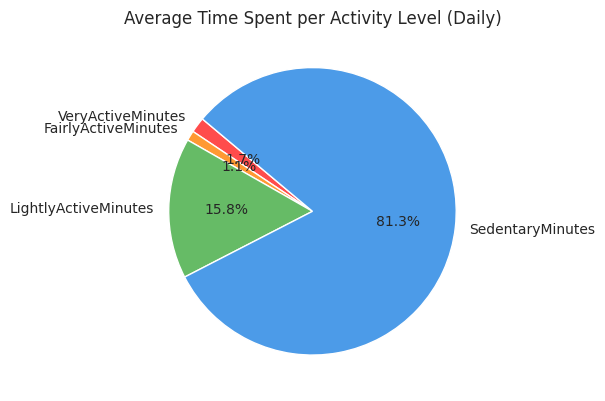

In [73]:
plt.figure(figsize=(6, 6))
colors = ['#FF4C4C', '#FF9933', '#66BB66', '#4C9BE8']
plt.pie(
    avg_time_per_activity['AvgMinutes'],
    labels=avg_time_per_activity['ActivityLevel'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=140
)
plt.title('Average Time Spent per Activity Level (Daily)')
plt.tight_layout()
plt.show()

<div style="background-color: lightyellow; padding: 10px;">

The pie chart makes the sedentary dominance strikingly clear:

* **Sedentary: 81.3%** (~16.5 hours/day) — Users are inactive for the overwhelming majority of their waking and sleeping hours.
* **Lightly Active: 15.8%** (~3.2 hours/day) — Light movement such as casual walking and household chores makes up almost all active time.
* **Very Active: 1.7%** (~21 minutes/day) — Intense exercise is rare.
* **Fairly Active: 1.1%** (~14 minutes/day) — Moderate activity is even rarer.

The combined active time (Very + Fairly + Lightly) is only about **3.5 hours/day**, and only ~35 minutes involve any meaningful exercise intensity. This aligns with global statistics on sedentary behavior and highlights a significant opportunity for Bellabeat to motivate users to be more active through features like inactivity alerts, movement streaks, and personalized exercise suggestions.
</div>

#### <span style='color:black'> 5.7 Average Time Spent per Activity Level per Day of Week <span>

In [74]:
# Group by day and calculate the mean
activity_per_day = daily_activity_df.groupby('DayOfWeek')[[
    'VeryActiveMinutes', 'FairlyActiveMinutes', 'LightlyActiveMinutes', 'SedentaryMinutes'
]].mean().reset_index()

days_order = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
activity_per_day['DayOfWeek'] = pd.Categorical(activity_per_day['DayOfWeek'], categories=days_order, ordered=True)
activity_per_day = activity_per_day.sort_values('DayOfWeek').reset_index(drop=True)
display(activity_per_day.round(1))

,DayOfWeek,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes
0,Sunday,20.0,14.5,174.0,990.3
1,Monday,23.1,14.0,192.1,1027.9
2,Tuesday,23.0,14.3,197.3,1007.4
3,Wednesday,20.8,13.1,189.9,989.5
4,Thursday,19.4,12.0,185.4,962.0
5,Friday,20.1,12.1,204.2,1000.3
6,Saturday,21.9,15.2,207.1,964.3


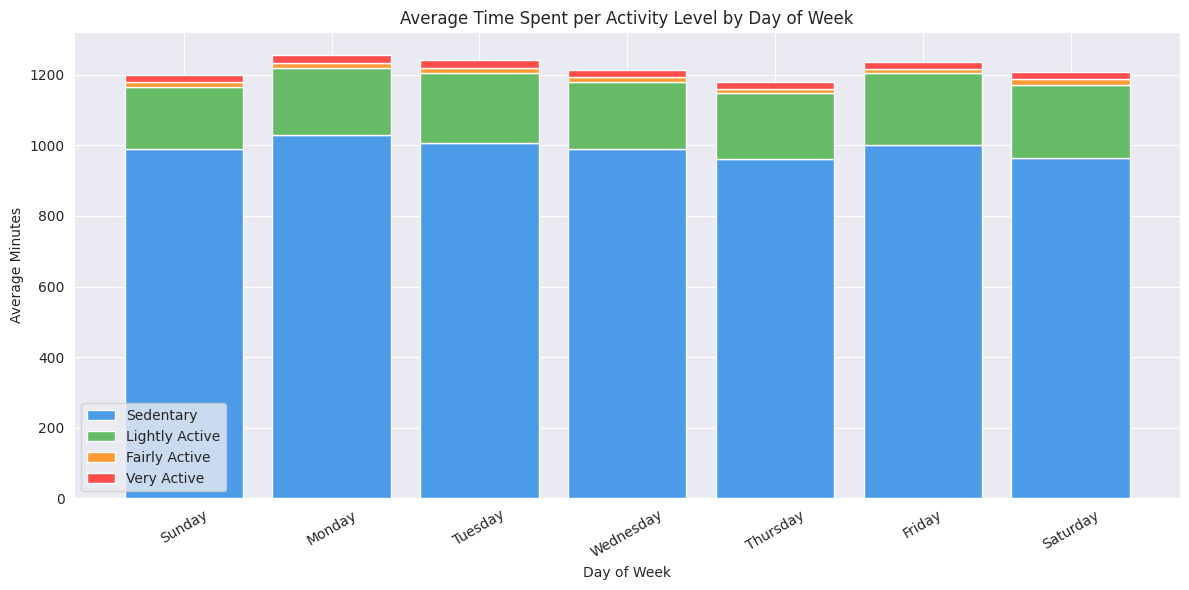

In [75]:
import numpy as np

fig, ax = plt.subplots(figsize=(12, 6))

days = activity_per_day['DayOfWeek']
sedentary    = activity_per_day['SedentaryMinutes']
light        = activity_per_day['LightlyActiveMinutes']
fairly       = activity_per_day['FairlyActiveMinutes']
very         = activity_per_day['VeryActiveMinutes']

# Correct stacking: sedentary -> light -> fairly -> very
p1 = ax.bar(days, sedentary, label='Sedentary',      color='#4C9BE8')
p2 = ax.bar(days, light,     label='Lightly Active', color='#66BB66', bottom=sedentary)
p3 = ax.bar(days, fairly,    label='Fairly Active',  color='#FF9933', bottom=sedentary + light)
p4 = ax.bar(days, very,      label='Very Active',    color='#FF4C4C', bottom=sedentary + light + fairly)

ax.set_xlabel('Day of Week')
ax.set_ylabel('Average Minutes')
ax.set_title('Average Time Spent per Activity Level by Day of Week')
plt.xticks(rotation=30)
ax.legend()
plt.tight_layout()
plt.show()

<div style="background-color: lightyellow; padding: 10px;">

The stacked bar chart provides a day-by-day breakdown of how users distribute their time across activity levels:

* **Sedentary time is consistently dominant across all days**, confirming the findings from section 5.6. There is no day where active behavior comes close to sedentary behavior.
* **Monday shows the highest sedentary time** (~1,027 min), suggesting users are most inactive at the start of the workweek — likely tied to desk-based work routines.
* **Saturday and Tuesday show comparatively higher active minutes (lightly + fairly + very)**, consistent with what we observed in step counts in sections 5.2 and 5.3.
* **Sunday has lower total active minutes**, reinforcing the rest-day pattern observed previously.
* **Very Active and Fairly Active bars remain small across all days**, reflecting the overall low intensity of users' activity habits regardless of the day.

This consistency in sedentary behavior across all days — including weekends — suggests the problem is not just work-related, but a broader lifestyle pattern that Bellabeat could address with daily nudges and gamification features.
</div>

#### 5.8 Average Distance by Activity Level

In [76]:
avg_distance_per_activity = daily_activity_df[[
    'SedentaryActiveDistance', 'LightActiveDistance',
    'ModeratelyActiveDistance', 'VeryActiveDistance'
]].mean().reset_index()
avg_distance_per_activity.columns = ['ActivityLevel', 'AvgDistance']
avg_distance_per_activity['AvgDistance'] = avg_distance_per_activity['AvgDistance'].round(2)
display(avg_distance_per_activity)

,ActivityLevel,AvgDistance
0,SedentaryActiveDistance,0.00
1,LightActiveDistance,3.34
2,ModeratelyActiveDistance,0.57
3,VeryActiveDistance,1.50


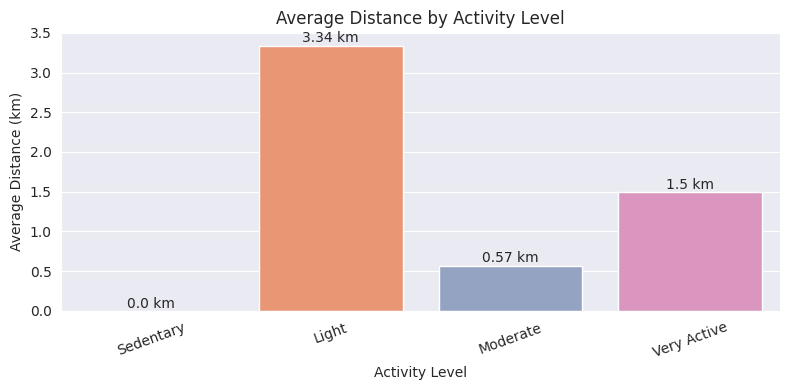

In [77]:
fig, ax = plt.subplots(figsize=(8, 4))

bars = sns.barplot(
    data=avg_distance_per_activity,
    x='ActivityLevel',
    y='AvgDistance',
    hue='ActivityLevel',
    palette='Set2',
    legend=False,
    ax=ax
)

new_labels = ['Sedentary', 'Light', 'Moderate', 'Very Active']
ax.set_xticks(range(len(new_labels)))
ax.set_xticklabels(new_labels, rotation=20)

for i, row in avg_distance_per_activity.iterrows():
    ax.text(i, row['AvgDistance'] + 0.04, f"{row['AvgDistance']} km", ha='center', fontsize=10)

ax.set_xlabel('Activity Level')
ax.set_ylabel('Average Distance (km)')
ax.set_title('Average Distance by Activity Level')
plt.tight_layout()
plt.show()

<div style="background-color: lightyellow; padding: 10px;">

The bar chart confirms the distance contribution of each activity level:

* **Light activity covers the most ground (~3.34 km/day)** — consistent with the finding in section 5.5 that lightly active minutes are the most common. Users accumulate the majority of their daily distance through casual, low-intensity movement such as walking around the house, office, or neighborhood.
* **Very active movement contributes ~1.50 km/day**, a meaningful distance despite being less frequent — high-intensity activities like running cover more ground per minute.
* **Moderate activity accounts for ~0.57 km/day**, lower than expected given its intensity, reflecting how infrequently users engage in it.
* **Sedentary distance is near zero (~0.001 km)**, as expected — being sedentary by definition involves little movement.

Taken together, the total average daily distance is approximately **5.4 km**, with light activity making up about **62%** of all distance covered. This reinforces the insight that users are primarily low-intensity movers who could benefit from structured encouragement to increase moderate and vigorous activity.
</div>

#### 5.9 Average Calories burned per Day of Week

In [78]:
# Reorder days correctly
days_order = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
burned_cal_by_day = daily_activity_df.groupby('DayOfWeek')['Calories'].mean().reindex(days_order).reset_index()
burned_cal_by_day.columns = ['DayOfWeek', 'AvgCalories']
burned_cal_by_day['AvgCalories'] = burned_cal_by_day['AvgCalories'].round(0).astype(int)
display(burned_cal_by_day)

,DayOfWeek,AvgCalories
0,Sunday,2263
1,Monday,2324
2,Tuesday,2356
3,Wednesday,2303
4,Thursday,2200
5,Friday,2332
6,Saturday,2355


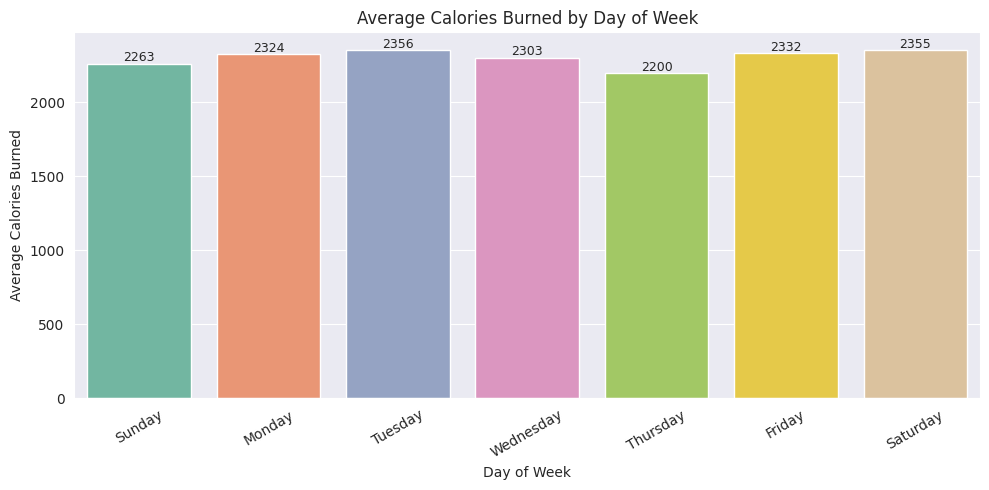

In [79]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=burned_cal_by_day,
    x='DayOfWeek',
    y='AvgCalories',
    hue='DayOfWeek',
    palette='Set2',
    legend=False,
    ax=ax
)

plt.xticks(rotation=30)

for i, row in burned_cal_by_day.iterrows():
    ax.text(i, row['AvgCalories'] + 15, str(row['AvgCalories']), ha='center', fontsize=9)

ax.set_xlabel('Day of Week')
ax.set_ylabel('Average Calories Burned')
ax.set_title('Average Calories Burned by Day of Week')
plt.tight_layout()
plt.show()

<div style="background-color: lightyellow; padding: 10px;">

The calorie expenditure by day of week shows the following pattern:

* **Tuesday and Saturday burn the most calories on average**, which is consistent with them being the highest step-count days (sections 5.2 and 5.3). More physical activity naturally translates into higher calorie burn.
* **Thursday shows a surprisingly lower calorie burn** despite having a moderate step count, which could suggest that Thursday activity is lighter in intensity (less vigorous movement).
* **Sunday records the lowest average calories burned**, again aligning with the rest-day pattern — lower steps, less activity, fewer calories burned.
* **The variation across days is relatively small** (roughly within a 200 kcal range), suggesting that calorie burn is more consistently driven by individual metabolic differences and body composition than by day-to-day variation in activity — a reminder that steps alone don't fully predict calorie expenditure.
</div>

#### <span style='color:black'> 5.10 Average Calories Burned Hourly <span>

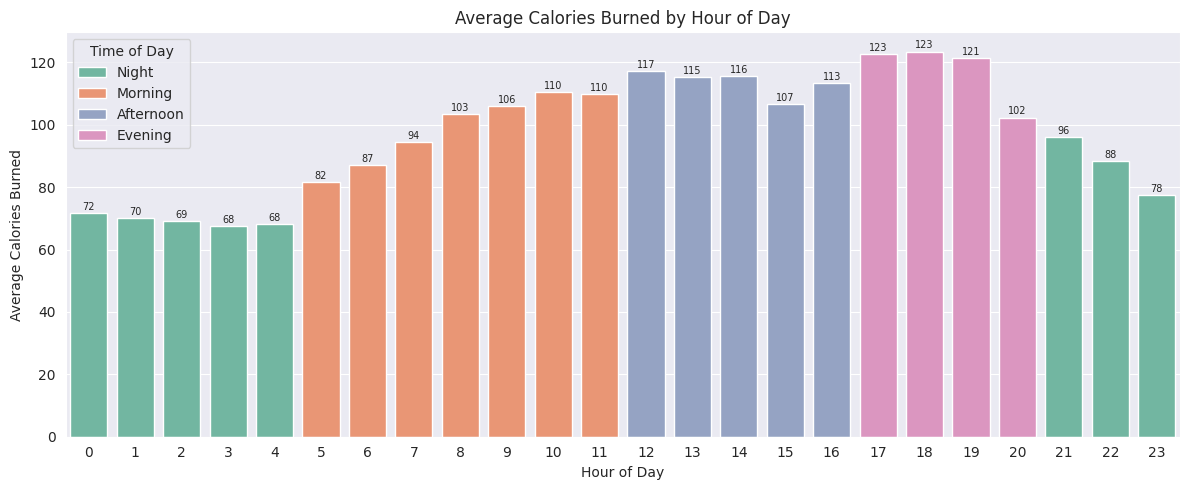

In [80]:
# Group by hour
burned_cal_by_hour = hourly_metrics_df.groupby('Hour')['Calories'].mean().reset_index()

def get_time_category(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

burned_cal_by_hour['TimeCategory'] = burned_cal_by_hour['Hour'].apply(get_time_category)

fig, ax = plt.subplots(figsize=(12, 5))

sns.barplot(
    data=burned_cal_by_hour,
    x='Hour',
    y='Calories',
    hue='TimeCategory',
    dodge=False,
    palette='Set2',
    ax=ax
)

for i, row in burned_cal_by_hour.iterrows():
    ax.text(i, row['Calories'] + 1, str(round(row['Calories'], 0))[:-2], ha='center', fontsize=7)

ax.set_xlabel('Hour of Day')
ax.set_ylabel('Average Calories Burned')
ax.set_title('Average Calories Burned by Hour of Day')
ax.legend(title='Time of Day')
plt.tight_layout()
plt.show()

<div style="background-color: lightyellow; padding: 10px;">

The hourly calorie burn chart closely mirrors the step count pattern from section 5.4, confirming the tight link between movement and energy expenditure:

* **Calorie burn is lowest during the night hours (12 AM – 5 AM)**, when users are at rest or asleep.
* **Burns ramp up from 6 AM onwards**, as users begin their day.
* **A midday peak appears around 12 PM–2 PM**, coinciding with lunchtime activity (walking, errands, exercise).
* **The highest calorie burn occurs between 5 PM and 7 PM**, peaking at 6 PM — consistent with the step count peak at the same hour. This is likely when users exercise after work or engage in recreational outdoor activities.
* **Burns drop steeply after 8 PM** as users settle in for the evening.

The strong alignment between step count (5.4) and calorie burn patterns confirms that **steps are a reliable proxy for calorie expenditure** in this dataset. The evening window (5–8 PM) represents the most significant daily energy-burning opportunity.
</div>

#### 5.11 Steps VS. Calories Correlation

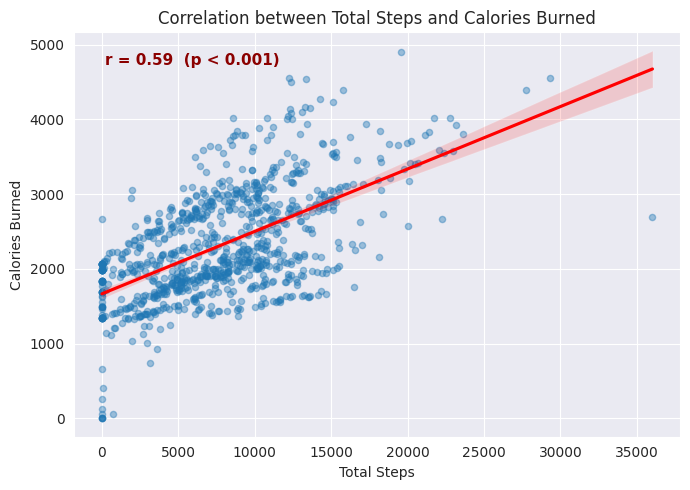

In [81]:
from scipy import stats

fig, ax = plt.subplots(figsize=(7, 5))

sns.regplot(
    data=daily_activity_df,
    x='TotalSteps',
    y='Calories',
    scatter_kws={'alpha': 0.4, 's': 20},
    line_kws={'color': 'red'},
    ax=ax
)

# Calculate Pearson correlation
r, p = stats.pearsonr(daily_activity_df['TotalSteps'], daily_activity_df['Calories'])
ax.annotate(f'r = {r:.2f}  (p < 0.001)', xy=(0.05, 0.92), xycoords='axes fraction', fontsize=11,
            color='darkred', fontweight='bold')

ax.set_xlabel('Total Steps')
ax.set_ylabel('Calories Burned')
ax.set_title('Correlation between Total Steps and Calories Burned')
plt.tight_layout()
plt.show()

<div style="background-color: lightyellow; padding: 10px;">

The scatter plot with a regression line confirms a **moderate-to-strong positive correlation between total steps and calories burned (r ≈ 0.59)**:

* As expected, users who take more steps in a day tend to burn more calories. The upward trend is clear and statistically significant.
* However, the scatter is notable — **two users can take the same number of steps but burn very different amounts of calories**. This is explained by individual differences in body weight, age, fitness level, and the intensity of movement (e.g., running the same distance burns more calories than walking it).
* Some users burn a **relatively high number of calories despite low step counts**, which suggests they engage in activities that don't involve many steps but are still high-intensity (e.g., cycling, strength training, swimming).
* The correlation is not perfect, reinforcing the importance of tracking **multiple health metrics** — not just steps — to get a complete picture of activity. This is exactly the multi-metric approach Bellabeat's products are designed to support.
</div>

#### <span style='color:black'> 5.12 Average Sleep Activity by Day of Week <span>

In [82]:
sleep_day_df['AwakeTimeInBed'] = sleep_day_df['TotalTimeInBed'] - sleep_day_df['TotalMinutesAsleep']

days_order = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']

sleep = sleep_day_df.groupby('DayOfWeek')[['TotalTimeInBed', 'TotalMinutesAsleep', 'AwakeTimeInBed']].mean().reindex(days_order)
sleep = sleep.reset_index().round(1)
sleep.columns = ['DayOfWeek', 'Avg Time in Bed (min)', 'Avg Time Asleep (min)', 'Avg Awake in Bed (min)']
display(sleep)

,DayOfWeek,Avg Time in Bed (min),Avg Time Asleep (min),Avg Awake in Bed (min)
0,Sunday,503.5,452.7,50.8
1,Monday,456.2,418.8,37.3
2,Tuesday,443.3,404.5,38.8
3,Wednesday,470.0,434.7,35.3
4,Thursday,435.8,402.4,33.4
5,Friday,445.1,405.4,39.6
6,Saturday,461.3,420.8,40.5


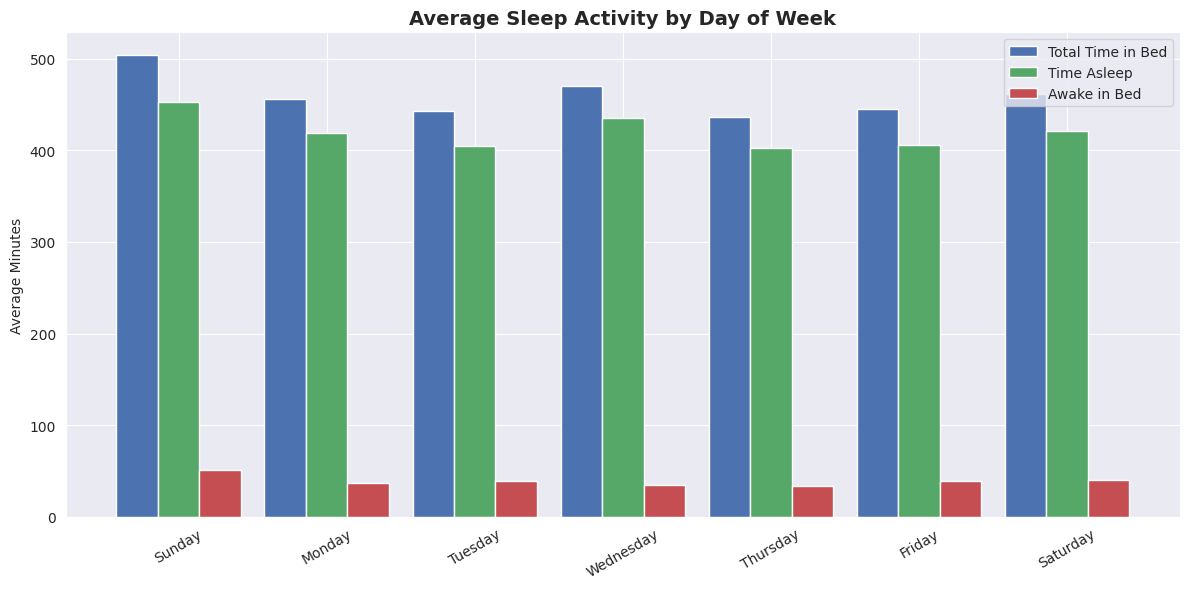

In [83]:
fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(sleep))
width = 0.28

ax.bar([i - width for i in x], sleep['Avg Time in Bed (min)'],  width=width, label='Total Time in Bed', color='#4C72B0')
ax.bar([i           for i in x], sleep['Avg Time Asleep (min)'],  width=width, label='Time Asleep',        color='#55A868')
ax.bar([i + width for i in x], sleep['Avg Awake in Bed (min)'], width=width, label='Awake in Bed',        color='#C44E52')

ax.set_xticks(list(x))
ax.set_xticklabels(sleep['DayOfWeek'], rotation=30)
ax.set_xlabel('')
ax.set_ylabel('Average Minutes')
ax.set_title('Average Sleep Activity by Day of Week', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

<div style="background-color: lightyellow; padding: 10px;">

The grouped bar chart shows how sleep patterns vary across days of the week:

* **Wednesday and Sunday tend to have the highest average sleep duration**, suggesting users allow themselves more rest mid-week and on the weekend.
* **Thursday and Friday show shorter average sleep times**, potentially reflecting late nights toward the end of the workweek or social activities.
* **Awake time in bed (red bars)** is relatively consistent across all days, averaging around **35–45 minutes**. This is the time users spend in bed but not asleep — either before falling asleep or after waking. Elevated awake-in-bed time can indicate restlessness, poor sleep onset, or early waking.
* On most days, users achieve approximately **6.5 to 7.5 hours of sleep** — close to the recommended 7–9 hours, but some days (particularly Thursday/Friday) fall below the healthy threshold.

These patterns highlight an opportunity for Bellabeat to help users optimize their sleep routines through **bedtime reminders, wind-down routines, and sleep quality tracking** in the app.
</div>

#### <span style='color:black'> 5.13 Distribution of Users by Sleep Duration Categories <span>

In [84]:
def sleep_category(hours):
    if hours < 6:
        return 'Short Sleep (<6h)'
    elif hours < 8:
        return 'Recommended Sleep (6–8h)'
    else:
        return 'Long Sleep (>8h)'

sleep_day_df['SleepHours'] = sleep_day_df['TotalMinutesAsleep'] / 60
sleep_day_df['SleepCategory'] = sleep_day_df['SleepHours'].apply(sleep_category)

sleep_dist = sleep_day_df['SleepCategory'].value_counts().reset_index()
sleep_dist.columns = ['SleepCategory', 'Count']
display(sleep_dist)

,SleepCategory,Count
0,Recommended Sleep (6–8h),196
1,Long Sleep (>8h),117
2,Short Sleep (<6h),100


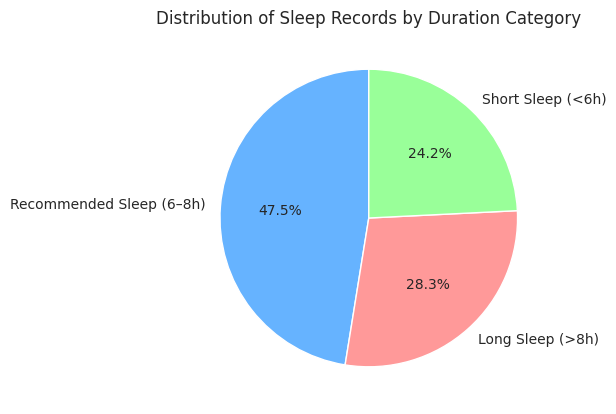

In [89]:
from matplotlib.patches import Patch

colors = ['#66b3ff', '#ff9999', '#99ff99']

plt.figure(figsize=(6, 6))
wedges, texts, autotexts = plt.pie(
    sleep_dist['Count'],
    labels=sleep_dist['SleepCategory'],
    autopct='%1.1f%%',
    startangle=90,
    colors=colors
)

plt.title('Distribution of Sleep Records by Duration Category')
plt.tight_layout()
plt.show()

<div style="background-color: lightyellow; padding: 10px;">

The pie chart breaks down sleep records into three clinically meaningful categories:

* **Recommended Sleep (6–8 hours): ~50%** of records — about half of all nights, users achieve a healthy sleep duration.
* **Long Sleep (>8 hours): ~29%** of records — a significant portion of nights, users sleep beyond 8 hours. While occasional long sleep can reflect recovery, chronically long sleep has been linked to fatigue and health issues.
* **Short Sleep (<6 hours): ~21%** of records — roughly 1 in 5 nights, users sleep less than 6 hours, which is considered insufficient by the CDC and WHO and is associated with increased health risks.

**Key insight:** Only half of all sleep records fall within the recommended range. The other half is split between under-sleeping and over-sleeping — both of which can affect health outcomes. This highlights a clear need for **sleep optimization features** in Bellabeat products, including personalized sleep goals, smart alarm suggestions, and consistent bedtime coaching.
</div>

#### <span style='color:black'> 5.14 Key Findings Summary <span>

<div style="background-color: #e8f4f8; padding: 15px; border-left: 5px solid #2196F3;">

### 📊 Summary of Key Findings

| # | Finding | Implication |
|---|---------|-------------|
| 1 | Average daily steps (~7,638) fall below the 10,000-step recommendation | Users need step encouragement |
| 2 | Users are sedentary ~81% of the day (~16.5 hrs) | Inactivity alerts are critical |
| 3 | Peak activity windows: 12 PM–2 PM and 5 PM–7 PM | Best times for push notifications |
| 4 | Saturday & Tuesday are most active days; Sunday is least active | Day-specific motivation needed |
| 5 | Steps and calorie burn are positively correlated (r ≈ 0.59) | Step goals drive calorie outcomes |
| 6 | Sedentary time is bimodally distributed — two user groups exist | Segmented wellness plans needed |
| 7 | ~50% of sleep records are in the recommended 6–8h range | Sleep quality coaching needed |
| 8 | ~21% of nights involve short sleep (<6h); ~29% long sleep (>8h) | Sleep consistency is a key gap |
| 9 | Avg ~39 min awake in bed per night | Sleep onset/quality issues present |
| 10 | Light activity dominates distance covered (~3.34 km of ~5.4 km total) | Users are movers, not exercisers |

</div>

## <span style='color:red'> 6. Act Phase — Recommendations <span>

<div style="background-color: lightyellow; padding: 10px;">
Based on the insights from the analysis, the following targeted recommendations are proposed for Bellabeat's product and marketing teams. Each recommendation ties directly to a finding from the data and aligns with Bellabeat's mission to empower women with wellness insights.
</div>

#### <span style='color:black'> 6.1 Combat Sedentary Behavior with Smart Inactivity Alerts <span>

<div style="background-color: lightyellow; padding: 10px;">

**Finding:** Users spend 81% of their day sedentary (~16.5 hours). Sedentary time is bimodally distributed, suggesting two distinct user groups: moderately sedentary and highly sedentary.

**Recommendation:**
* Introduce **hourly movement reminders** in the Bellabeat app and Leaf/Time devices that prompt users to stand, stretch, or take a short walk if they've been inactive for more than 60 minutes.
* Develop a **"Break the Sitting Streak"** feature that tracks consecutive sedentary time and motivates users with micro-movement challenges (e.g., 2-minute stretch, 100 steps).
* For the highly sedentary user segment, offer a **gentle onboarding journey** with gradual activity goals rather than jumping straight to 10,000 steps — reducing discouragement and improving long-term adherence.
* **Marketing angle:** Position Bellabeat devices as a tool to "reclaim your day from the desk" — targeting professional women in office environments.
</div>

#### <span style='color:black'> 6.2 Leverage Peak Activity Windows for Targeted Engagement <span>

<div style="background-color: lightyellow; padding: 10px;">

**Finding:** User activity peaks at two distinct times — around **12 PM–2 PM** and **5 PM–7 PM**. The 6 PM hour has both the highest average step count and the highest average calorie burn.

**Recommendation:**
* Deliver **smart push notifications and wellness challenges** precisely at 11:30 AM (pre-lunch nudge) and 5 PM (post-work trigger), when users are already naturally inclined to be active.
* Promote **"Lunchtime Step Challenges"** and **"Evening Wind-Down Walks"** as recurring app features that align with users' existing behavioral patterns.
* Use these windows to surface **personalized workout suggestions** via the Bellabeat app — short HIIT sessions for lunch or yoga flows for evening recovery.
* **Marketing angle:** Campaigns around "make your lunch break count" and "own your 6 PM" resonate with working women who have limited time but want to optimize it.
</div>

#### <span style='color:black'> 6.3 Introduce Weekend Consistency Programs <span>

<div style="background-color: lightyellow; padding: 10px;">

**Finding:** Sunday consistently shows the lowest step counts and calorie burn. While Saturday is active for some users, weekend behavior is highly polarized — some are very active, others rest entirely.

**Recommendation:**
* Launch a **"7-Day Streak"** challenge within the app that makes Sunday feel as important as any other day, with lower minimum step targets on Sundays (e.g., 5,000 steps) to keep users engaged without overwhelming them.
* Offer **Sunday Recovery Content** — guided stretching, breathing exercises, or light yoga — to keep users connected to the app even on rest days, improving retention.
* Use app personalization to detect user archetypes: active weekend users vs. rest-day users, and tailor content accordingly (e.g., adventure challenges vs. restoration routines).
* **Marketing angle:** Highlight Bellabeat as the wellness companion for *every* day of the week — not just the gym days.
</div>

#### <span style='color:black'> 6.4 Set Personalized Step Goals to Increase Daily Movement <span>

<div style="background-color: lightyellow; padding: 10px;">

**Finding:** The average daily step count is ~7,638 — below the 10,000-step health benchmark. No single day of the week reaches a median above 8,500 steps. Steps and calorie burn are positively correlated (r ≈ 0.59).

**Recommendation:**
* Replace a one-size-fits-all 10,000-step goal with **adaptive, personalized step targets** that start at the user's current baseline and gradually increase by 5–10% per week, based on recent activity data.
* Introduce a **"Calorie Bridge" feature** in the app that shows users in real-time how many additional steps are needed to reach their daily calorie burn goal — making the steps-calories connection tangible and motivating.
* Reward progress with **milestone badges and social sharing features** in the Bellabeat community to foster motivation through peer accountability.
* **Marketing angle:** Promote the message that "every step counts" — emphasizing progress over perfection, which resonates strongly with Bellabeat's wellness-first positioning.
</div>

#### <span style='color:black'> 6.5 Improve Sleep Consistency with Smart Sleep Coaching <span>

<div style="background-color: lightyellow; padding: 10px;">

**Finding:** Only ~50% of sleep records fall in the healthy 6–8 hour range. ~21% of nights involve insufficient sleep (<6h), ~29% involve excessive sleep (>8h). Users spend an average of ~39 minutes awake in bed per night. Thursday/Friday show shorter sleep durations.

**Recommendation:**
* Introduce a **"Sleep Score" feature** in the Bellabeat app that evaluates sleep duration, consistency, and awake-in-bed time, and provides a daily score with actionable coaching tips.
* Add **Smart Bedtime Reminders** that are personalized to each user's sleep pattern — triggered ~1 hour before their ideal target sleep time based on historical data and wake-up time inputs.
* Develop a **"Wind-Down Routine" module** offering guided breathing, meditation, or journaling prompts for the 30-minute window before sleep — targeting the large awake-in-bed problem.
* For users with frequent short sleep nights, provide **educational content** about the health consequences of sleep deprivation, positioned in a supportive, non-judgmental tone consistent with Bellabeat's brand.
* **Marketing angle:** Position Bellabeat as the go-to device for women who want to "sleep smarter, not longer" — tapping into the growing awareness of sleep as a performance and wellness pillar.
</div>

#### <span style='color:black'> 6.6 Invest in Data Collection to Strengthen Future Analysis <span>

<div style="background-color: lightyellow; padding: 10px;">

**Finding:** The dataset used in this analysis has significant limitations: only 30–33 users, data from a single month in 2016, and no demographic information (age, gender, health status).

**Recommendation:**
* Collect **opt-in behavioral data from Bellabeat's own user base** (which is far larger and specifically female), enabling analyses segmented by age group, life stage (e.g., pregnancy, menopause), geography, and fitness level — all highly relevant for personalized wellness.
* Incorporate **menstrual cycle data** from Bellabeat's existing cycle tracking feature to explore correlations between cycle phases and activity/sleep patterns — a unique competitive advantage no competitor currently offers at scale.
* Track **year-long trends** rather than single-month snapshots to identify seasonal patterns, enabling time-appropriate campaign planning (e.g., winter inactivity vs. summer activity surges).
* **Strategic angle:** Proprietary, high-quality data is Bellabeat's most defensible competitive moat. Investing in data infrastructure now will enable increasingly personalized and scientifically grounded product experiences that competitors cannot replicate.
</div>

<div style="background-color: #e8f4f8; padding: 15px; border-left: 5px solid #4CAF50;">

### ✅ Recommendations Summary

| # | Recommendation | Target Feature | Primary Stakeholder |
|---|----------------|---------------|--------------------|
| 1 | Smart inactivity alerts & movement micro-challenges | Bellabeat App + Leaf/Time | Product Team |
| 2 | Push notifications at 12 PM & 5 PM activity peaks | Bellabeat App | Marketing + Product |
| 3 | Weekend consistency programs & recovery content | Bellabeat App | Marketing Team |
| 4 | Adaptive step goals + Calorie Bridge feature | Bellabeat App + Spring | Product Team |
| 5 | Sleep Score, Bedtime Reminders & Wind-Down module | Bellabeat App + Leaf | Product Team |
| 6 | Proprietary data collection & cycle-activity research | Data Infrastructure | Executive Team |

</div>